# **Tutorial 2 Cross-resolution panel integration in weakly anchored spatial omics data**

Our data are organized as follows: the `datasets` directory stores the raw datasets, the `inputs` directory contains input data such as the pre-extracted H&E embeddings and filtered cell indices, and the `outputs` directory stores the model outputs.

```
our_model/
│
├── datasets/                  # The datasets
│   ├── ...                   
│
├── inputs/                    # The inputs
│   ├── ...
│
├── outputs/                   # The outputs
│   ├── ... 
```

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import SpaWeaver as sw
import matplotlib.pyplot as plt
import torch.multiprocessing as mp

## 1. Prepare the dataset

### [Download](https://www.10xgenomics.com/platforms/visium/product-family/dataset-human-crc) the Human Colon Cancer P2 dataset. Considering the large size of the raw dataset, we provide the related data, cell_feature_matrix.h5, cells.csv, and VisiumHD_P2_CRC.h5ad. These data should be organized into the following directory structure:

```
datasets/
│
├── Human_Colon_Cancer_P2/
│    ├── Xenium          # The 1st slice
│    │    ├── cell_feature_matrix.h5
│    │    ├── cells.csv
│    │    
│    ├── VisiumHD        # The 2nd slice          
│    │    ├── VisiumHD_P2_CRC.h5ad
```

For convenience, we provide image embeddings extracted by the H&E foundation model UNI from both the original H&E images and the HED-enhanced H&E images. In addition, we provide the corresponding cell indices for the sequenced cells. The relevant data are stored in the `inputs` directory, where each subdirectory contains the following files.

**he_emb**: Xenium_P2_CRC.npy and VisiumHD_P2_CRC.npy

**cell_filter**: Xenium_P2_CRC.npy and VisiumHD_P2_CRC.npy

```
inputs/
│
├── cell_filter/                  # Stores the filtered cell indices
│   ├── Xenium_P2_CRC.npy         # Xenium              
│   ├── VisiumHD_P2_CRC.npy       # Visium
│
├── he_emb/                       # Store the extracted H&E image embeddings.
│   ├── Xenium_P2_CRC.npy         # Xenium                 
│   ├── VisiumHD_P2_CRC.npy       # Visium
```

**We have uploaded the associated data to Zenodo, which can be accessed through this [link](https://zenodo.org/records/20428441).**

## 2. Run the model

### 2.1 Define the arguments

In [2]:
sys.argv = [sys.argv[0], "--epoch", "2000", "--hops", "1"]
args = sw.args.build_args()
print(args)

Namespace(seed=0, device=0, optimizer='adam', load_model=False, hops=1, pe_dim=128, hidden_dim=128, n_layers=1, n_heads=2, dropout=0.1, attention_dropout=0.1, activation='elu', epoch=2000, batch_size=4096, loss_fn='mse', lr=0.001, weight_decay=0, sample_name1='Human_Breast_Cancer_Rep1', root_path1='./datasets/Human_Breast_Cancer_Rep1/', sample_name2='Human_Breast_Cancer_Rep2', root_path2='./datasets/Human_Breast_Cancer_Rep2/', save=True, save_tag='fig2', output_folder='./outputs/', image_encoder='uni', img_batch_size=64, num_neighbors=7, scale=0.363788, cell_diameter=-1, resolution=64, mmd_weight=0.01)


The parameters defined above can be adjusted according to your experimental settings.

In [3]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2,3' # Specify the visible GPUs, as multi-GPU training is utilized in the following code.
world_size = 4 # the number of gpus

args.root_path1 = './datasets/Human_Colon_Cancer_P2/Xenium/'
args.root_path2 = './datasets/Human_Colon_Cancer_P2/VisiumHD/'
args.output_folder = './outputs/'
args.save_tag = 'fig3'

if not os.path.exists("./outputs/"):
    os.makedirs("./outputs/")

args.output_folder = './outputs/'
args.save_tag = 'fig3'

if not os.path.exists("./outputs/model/fig3"):
    os.makedirs("./outputs/model/fig3")

if not os.path.exists("./outputs/result/fig3"):
    os.makedirs("./outputs/result/fig3")

sw.utils.set_random_seed(args.seed)
meta_root = './inputs/'

print("complete!")

complete!


###  2.2 Loading data

In [5]:
print("📥 Loading Xenium data...")
adata1 = sw.pp.read_Xenium(args.root_path1)
adata2 = sw.pp.read_VisiumHD(args.root_path2)
adata1 = sw.pp.load_he_emb(adata1, meta_root, 'Xenium_P2_CRC')
adata2 = sw.pp.load_he_emb(adata2, meta_root, 'VisiumHD_P2_CRC')
print("complete!")

📥 Loading Xenium data...
complete!


In [7]:
sc.pp.filter_cells(adata1, min_counts=50)
sc.pp.filter_cells(adata2, min_counts=50) 
sc.pp.filter_genes(adata1, min_cells=1)                   
adata2 = sw.pp.mt_qc(adata2)   

adata1, adata2

(AnnData object with n_obs × n_vars = 263703 × 422
     obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_counts'
     var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
     obsm: 'spatial', 'he',
 AnnData object with n_obs × n_vars = 467135 × 18060
     obs: 'array_row', 'array_col', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_MT-', 'pct_counts_MT-'
     var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'MT-', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
     obsm: 'image_coor', 'spatial', 'he')

### 2.2 Panel partitioning

In [8]:
var1 = adata1.var_names[~adata1.var_names.str.startswith("MT-")]
var2 = adata2.var_names[~adata2.var_names.str.startswith("MT-")]
var_common = var1.intersection(var2)
panelA, panelB = var_common[:len(var_common)//2], var_common[len(var_common)//2:]

print("complete!")

complete!


### 2.3 Gene expression preprocessing

In [9]:
print("🧼 Preprocessing...")
adata1 = sw.pp.preprocess_rna(adata1, selected_genes=panelA)
adata2 = sw.pp.preprocess_rna(adata2, selected_genes=panelB)

print("complete!")

🧼 Preprocessing...
complete!


### 2.4 Bulid graphs, datasets, and models

In [11]:
print("🕸️ Building graphs (KNN)...")

adata2.obsm['spatial'] = adata2.obsm['spatial'].astype(float)
H1 = sw.pp.build_graph(adata1.obsm['spatial'], graph_type='knn', num_neighbors=args.num_neighbors, return_type='csr', apply_normalize='both')
H2 = sw.pp.build_graph(adata2.obsm['spatial'], graph_type='knn', num_neighbors=args.num_neighbors, return_type='csr', apply_normalize='both')

args.device = 'cpu'
print("🧩 Aggregating neighborhood features...")
node_HE_fea1 = sw.utils.re_features(H1, adata1.obsm['he'], args.hops, device=args.device)
node_HE_fea2 = sw.utils.re_features(H2, adata2.obsm['he'], args.hops, device=args.device)
adata1.obsm['he_sp'], adata2.obsm['he_sp'] = node_HE_fea1, node_HE_fea2

print("🧠 Building model...")
model_1 = sw.model.transformerModel(hops=args.hops,
                           input_dim=args.hidden_dim,
                           n_layers=args.n_layers,
                           num_heads=args.n_heads,
                           hidden_dim=args.hidden_dim,
                           dropout_rate=args.dropout,
                           attention_dropout_rate=args.attention_dropout)

mlp_1 = sw.model.OneLayerMLP(node_HE_fea1.shape[-1], args.hidden_dim) 
reg_1 = sw.model.OneLayerMLP(args.hidden_dim, adata1.n_vars)
reg_2 = sw.model.OneLayerMLP(args.hidden_dim, adata2.n_vars)
models = torch.nn.ModuleList([model_1, mlp_1, reg_1, reg_2])

🕸️ Building graphs (KNN)...
🧩 Aggregating neighborhood features...
🧠 Building model...


### 2.5 Train the model

Training function with GPU acceleration

In [12]:
print("🚀 Training...")
os.environ['MASTER_ADDR'] = 'localhost'
os.environ['MASTER_PORT'] = str(sw.utils.find_free_port())
mp.spawn(sw.PT.train, args=(world_size, args, adata1, adata2, models), nprocs=world_size, join=True)

🚀 Training...
Using port: 29500
====== Dataset Comprison: Data 1=16 batches, Data 2=28 batches ======
Data 2 data more，Automatically iterate over the Data 1 dataset...


🧠 Training: 100%|██████████| 2000/2000 [1:41:23<00:00,  3.04s/it]


💾 Saving checkpoint...
✅ Checkpoint saved to ./outputs/model/fig3/models.pt.


### 2.6 Test the model

In [13]:
print("🧪 Running inference...")
checkpoint = torch.load(f'{args.output_folder}model/{args.save_tag}/models.pt', map_location='cpu')
model_1.load_state_dict(checkpoint['model_1'])
mlp_1.load_state_dict(checkpoint['mlp_1'])
reg_1.load_state_dict(checkpoint['reg_1'])
reg_2.load_state_dict(checkpoint['reg_2'])
model_1.eval()
mlp_1.eval()
reg_1.eval()
reg_2.eval()

HE1 = model_1(mlp_1(torch.Tensor(node_HE_fea1)))
HE2 = model_1(mlp_1(torch.Tensor(node_HE_fea2)))
panelA1 = reg_1(HE1).detach().cpu().numpy()
panelB1 = reg_2(HE1).detach().cpu().numpy() # panel B of slice 1
panelA2 = reg_1(HE2).detach().cpu().numpy() # panel A of slice 2
panelB2 = reg_2(HE2).detach().cpu().numpy()
index1, index2 = adata1.obs.index, adata2.obs.index
if args.save:
    print("💾 Saving outputs...")

    df1 = pd.DataFrame(panelA1, index=index1, columns=panelA)
    df2 = pd.DataFrame(panelA2, index=index2, columns=panelA)
    df3 = pd.DataFrame(panelB1, index=index1, columns=panelB)
    df4 = pd.DataFrame(panelB2, index=index2, columns=panelB)
    df1.to_csv(f'{args.output_folder}result/{args.save_tag}/A1.csv')
    df2.to_csv(f'{args.output_folder}result/{args.save_tag}/A2.csv')
    df3.to_csv(f'{args.output_folder}result/{args.save_tag}/B1.csv')
    df4.to_csv(f'{args.output_folder}result/{args.save_tag}/B2.csv')
    print(f"✅ Outputs saved to {args.output_folder}result/{args.save_tag}/.")

🧪 Running inference...
💾 Saving outputs...
✅ Outputs saved to ./outputs/result/fig3/.


## 3. Evaluation

### 3.1 Visualization

In [14]:
file_root = f'{args.output_folder}result/{args.save_tag}/'
B1 = pd.read_csv(file_root + 'B1.csv', index_col=0)
A2 = pd.read_csv(file_root + 'A2.csv', index_col=0)
B1.index, A2.index = B1.index.astype(str), A2.index.astype(str)
obs1, obs2, var1, var2 = B1.index, A2.index, A2.columns, B1.columns

In [15]:
adataB1 = sw.pp.read_Xenium(args.root_path1 + 'cell_feature_matrix.h5', args.root_path1 + 'cells.csv')[obs1]
adataA2 = sw.pp.read_VisiumHD(args.root_path2)[obs2]
adataB1 = sw.pp.preprocess_rna(adataB1, selected_genes=var2)
adataA2 = sw.pp.preprocess_rna(adataA2, selected_genes=var1)

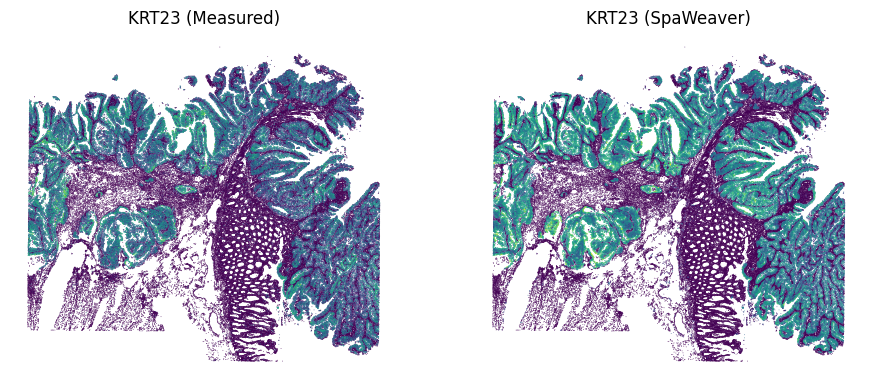

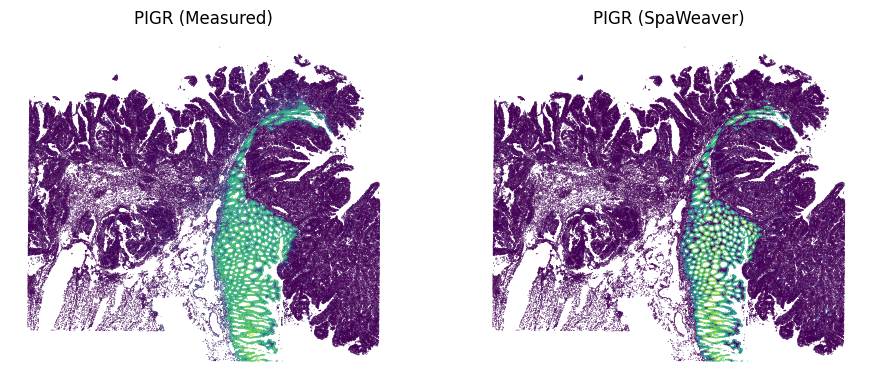

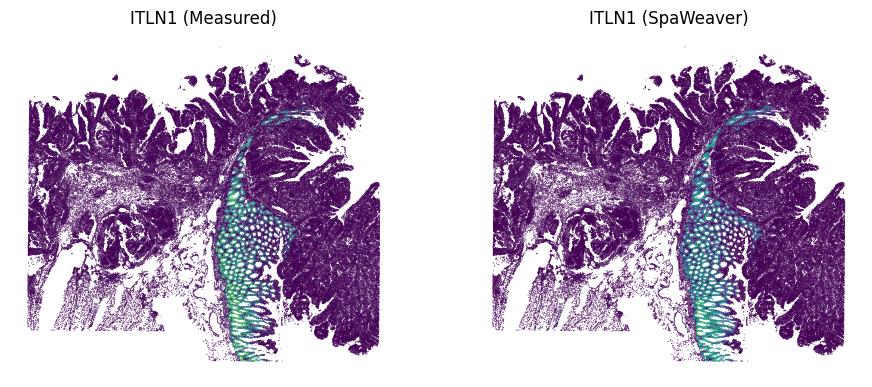

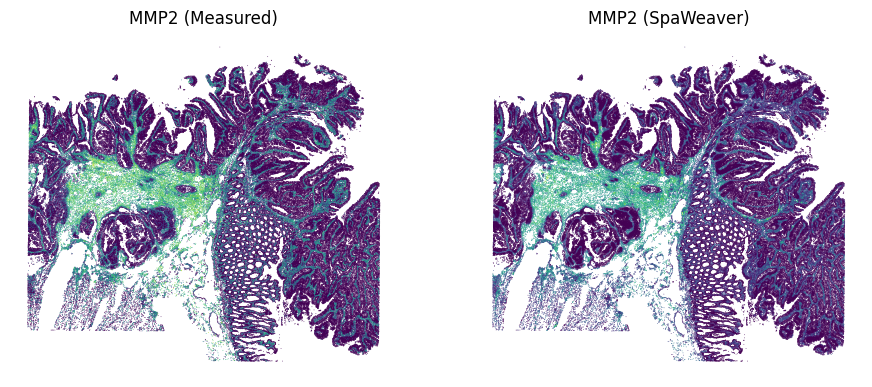

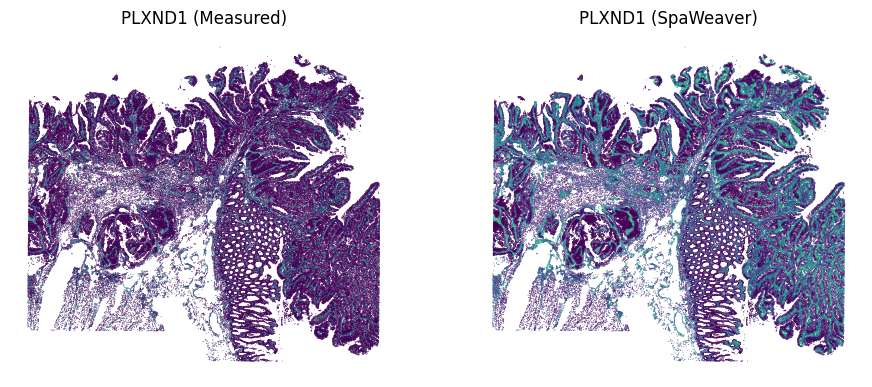

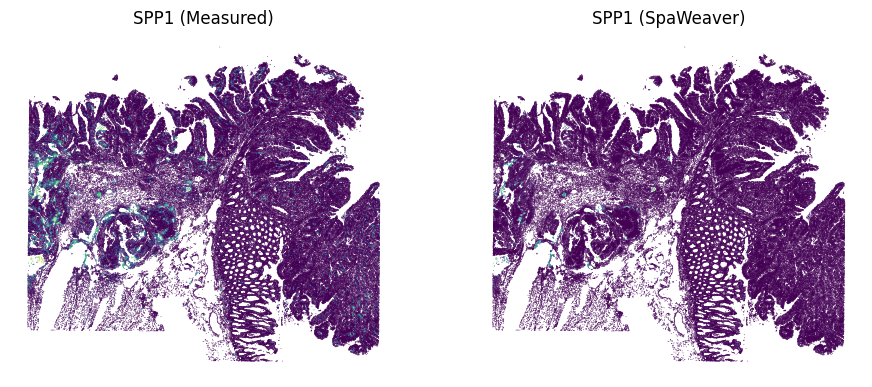

In [19]:
spatial = (-1)*adataB1.obsm['spatial']

gene_list = ['KRT23', 'PIGR', 'ITLN1', 'MMP2', 'PLXND1', 'SPP1']
for gene_name in gene_list:
    plt.figure(figsize=(11, 6))
    
    plt.subplot(1, 2, 1)
    value = adataB1[:, gene_name].X.squeeze()
    order = np.argsort(value)
    plt.scatter(spatial[order, 1], spatial[order, 0], c=value[order], s=0.3, vmin=0, edgecolor='none', rasterized=True)
    plt.gca().set_aspect(1)
    plt.axis('off')
    plt.title(gene_name + ' (Measured)')

    plt.subplot(1, 2, 2)
    value = B1[gene_name].values.squeeze()
    order = np.argsort(value)
    plt.scatter(spatial[order, 1], spatial[order, 0], c=value[order], s=0.3, vmin=0, edgecolor='none', rasterized=True)
    plt.gca().set_aspect(1)
    plt.axis('off')
    plt.title(gene_name + ' (SpaWeaver)')
    
    plt.show()